<a href="https://colab.research.google.com/github/xhy783/xue-1st-pro/blob/main/%E2%80%9CTP_Laplace_Students_ipynb%E2%80%9Dcopie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Context
Lower leg symptoms of chronic venous insufficiency (CVI) have an important clinical and economic impact as they may affect 15% to 33% of the general population and their prevalence increases with age. The symptoms of CVI is thought to be linked to the improvement of venous hypertension and venous flow. Compression stockings are the mainstay of conservative treatment in CVI. The objective of compressive stocking therapy is to provide external compression to the leg and to oppose to the hydrostatic forces of venous hypertension through the increase of tissue pressure. Treatment with these stockings results in a significant improvement in pain, swelling, and well-being if high compliance is achieved and this treatment is recommended in all grade of CVI.

![CVI](https://imgur.com/G9KBhys.jpg)

Here, it is proposed to investigate various ways of modeling compression effect of a given stocking, from the French standard, then using a simple analytical approach taking into account local curvature radius, last including the leg deformation.

This approach can be generalized to many textile-based medical devices, such as orthopedic braces, bandages, etc.


## Laplace's Law
Laplace's Law is a simple analytical approach for modeling the relationship between the pressure inside a curved surface and the tension. It is often used in the context of blood vessels, but can also be used here.

**Question** - Given a cylinder with a constant radius R. An elastic band is stretched and applied on the cylinder with a constant tension T. Write the mechanical equilibrium on the band for an infinitesimal angle δθ. Derive the Laplace formula relating the tension and pressure. Check that units are consistent. What are the main limitations of this approach?

![Laplace](https://imgur.com/XsKGGZP.jpg)

**Answer** - Let's consider a small element of the band of length R dθ. The forces acting on this element are the tension T and the pressure P. The tension T is tangent to the band, and the pressure P is normal to the band. The equilibrium of forces in the normal direction gives:

$$T \sin(\delta \theta) = P R \delta \theta$$

Assuming that the angle is small, we can approximate $\sin(\delta \theta) \approx \delta \theta$ and we get:

$$T = P R$$

The pressure P is defined as the force per unit area, so it has units of force divided by area, i.e. N/m². The tension T is a force, so it has units of N. The radius R has units of length, so the units are consistent.

The main limitations of this approach is that it assumes that the wall is isotropic, homogeneous, and that the underlying material is rigid. It also assumes that the wall is thin and that the pressure is uniform.

In [ ]:
# Import the data for this Notebook

import os

os.chdir('/content')
repo_path = 'bmed-tp-laplace'

# Check if the repository has already been cloned
if (not os.path.exists(repo_path)):
    # If not, clone it
    !git clone https://gitlab.emse.fr/pierrat/bmed-tp-laplace.git {repo_path}

# Change to the repository directory
os.chdir(repo_path)

Cloning into 'bmed-tp-laplace'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 16 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 567.90 KiB | 869.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.


# Leg geometry

It is convenient to represent the leg in a polar coordinate system. By executing the following lines, you will load a real patient's leg (in 2D).

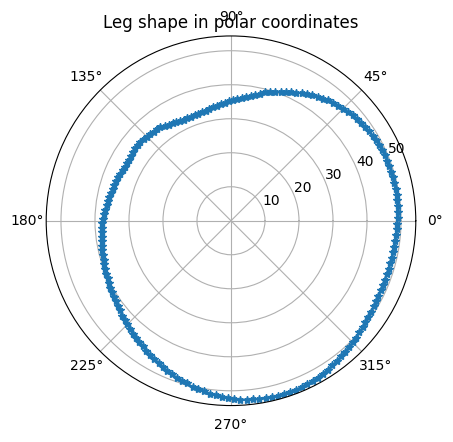

In [ ]:
import numpy as np

leg_points = np.loadtxt('Data/jambe.txt', delimiter=',')

# Cartesian to polar coordinates
X = leg_points[:, 0]
Y = leg_points[:, 1]
r = np.sqrt(X**2 + Y**2)
theta = np.arctan2(Y, X)

# Plot the shape in polar coordinates
import matplotlib.pyplot as plt
plt.figure()
plt.polar(theta, r, '-*')
plt.title('Leg shape in polar coordinates')
plt.show()


Because no pressure can be applied in concave areas, take the convex hull of the leg. The convex hull is the smallest convex polygon that contains all the points of the leg.

**Extract the convex hull, extract the points, and show the result as a polar plot.**

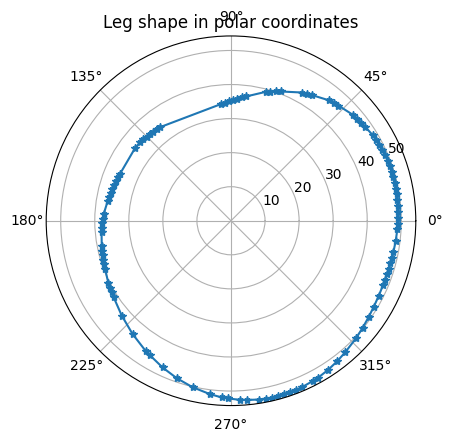

In [14]:
from scipy.spatial import ConvexHull

# Compute the convex hull
hull = ConvexHull(leg_points)
# print(leg_points)
# print(hull)
# source:instructions https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.ConvexHull.html
# plt.plot(leg_points[hull.vertices,0], leg_points[hull.vertices,1], 'r--', lw=2)
X=leg_points[hull.vertices,0]
Y=leg_points[hull.vertices,1]
r = np.sqrt(X**2 + Y**2)
theta = np.arctan2(Y, X)

# Plot the shape in polar coordinates
import matplotlib.pyplot as plt
plt.figure()
plt.polar(theta, r, '-*')
plt.title('Leg shape in polar coordinates')
# Show the points in a polar plot

plt.show()




As you can observe, now there are some gaps where the shape had local concavity. We would like to resample the function $r = f(\theta)$ at regular intervals to cover these gaps. The `scipy` library contains a convenient function to perform a smooth interpolation using Pchip : https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.pchip_interpolate.html.

**Complete the following code to interpolate r over 100 theta points in the $[-\pi; \pi]$ interval:**

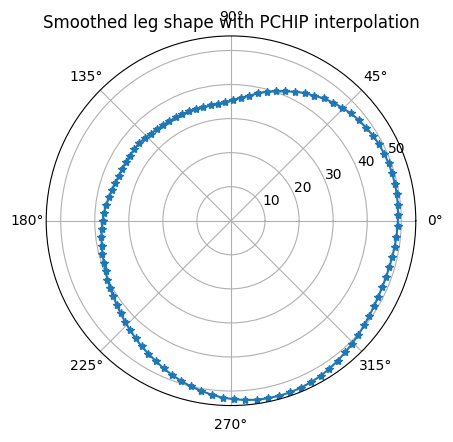

In [23]:
# Reorder theta in increasing order
sorted_idx = np.argsort(theta)
theta = theta[sorted_idx]
r = r[sorted_idx]

from scipy.interpolate import pchip_interpolate

# Create the regular theta vector
theta_regu = np.linspace(-np.pi, np.pi, 100)


# Interpolate at regular theta
r_regu = pchip_interpolate(theta, r, theta_regu)

# Plot the points on a polar graph
plt.figure()
plt.polar(theta_regu, r_regu, '-*')
plt.title('Smoothed leg shape with PCHIP interpolation')
plt.show()


X=r_regu * np.cos(theta_regu)
Y=r_regu * np.sin(theta_regu)

## Estimate the radius of curvature

In a general way, the radius of curvature is not constant. As a consequence, we need to calculate it from a set of experimental points

$ \gamma(i) = (x(i), y(i)), 1 < i < N$

Open the Wikipedia page for “Curvature” and extract the 1D expression of the curvature. **Which intermediate quantities need to be computed?**

Technically, we have a discrete approximation of the leg contour, which may include a bit of measurement noise. Gradients can be estimated at every point of the leg using a local polynomial approximation over $2*n+1$ points using the numpy function `polyfit`.

**Complete the function to compute the curvature and use the `estimate_curvature` function to estimate the curvature of the leg for different $n$ values.**

In [36]:
def estimate_curvature(X, Y, n, degree=2):
    """
    Estimate the curvature at every point of the leg using a local polynomial approximation for polar coordinates.

    Parameters:
    X (numpy.ndarray): X coordinates of the shape.
    Y (numpy.ndarray): Y coordinates of the shape.
    n (int): Number of points to use for the local polynomial approximation (n points before and after the current point).
    degree (int): Degree of the polynomial to fit.

    Returns:
    numpy.ndarray: Curvature at each point.
    """
    n_points = len(X)
    curvature = np.zeros(n_points)

    for i in range(n_points):
        # Select local points
        idx = np.arange(i-n, i+n+1)

        # Edge case
        wrapped_idx = np.mod(idx, n_points)

        x_local = X[wrapped_idx]
        y_local = Y[wrapped_idx]

        # Fit a polynomial to the local points
        p_x = np.polyfit(idx, x_local, degree)
        p_y = np.polyfit(idx, y_local, degree)

        # Compute the first and second derivatives and evaluate them at i
        dx = np.polyval(np.polyder(p_x, 1), i)
        ddx = np.polyval(np.polyder(p_x, 2), i)
        dy = np.polyval(np.polyder(p_y, 1), i)
        ddy = np.polyval(np.polyder(p_y, 2), i)

        # Compute the curvature
        curvature[i] = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**(3 / 2)

    return curvature

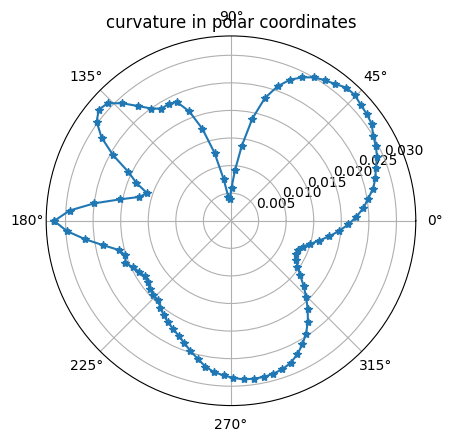

In [47]:
# Use the function on the leg data
kappa = estimate_curvature(X, Y, 6)
# print(kappa)



# Plot the shape in polar coordinates
plt.figure()
plt.polar(theta_regu, kappa, '-*')
plt.title('curvature in polar coordinates')
# Show the points in a polar plot
plt.show()


**What should be the most appropriate $n$ value?**



## Compression of the leg

**Estimate the length L of the leg contour from the set of points.**

In [56]:
import numpy as np

# Calculate the distance between each pair of adjacent points.
distances = np.sqrt(np.diff(X)**2 + np.diff(Y)**2)

# Sum up all distances to obtain the total length L.
L = np.sum(distances)
print(f"Length of the leg contour: {L:.3f} mm")

Length of the leg contour: 279.227 mm


We use medical stocking with a stiffness **k = 0.39 N/mm**. After measurement, the circumference of the stocking at the same height as the set of points ‘jambe.txt’ of the leg is **227.4 mm**.

**What is the mean strain applied to the stocking? Discuss the validity of engineering strain compared to the true strain (see https://en.wikipedia.org/wiki/Deformation_(physics)#Engineering_strain for definition if necessary).**

In [50]:
C_stocking = 227.4  # Circumference of the compression stocking, unit: mm
mean_strain = (L - C_stocking) / C_stocking
print(f"Mean strain applied to the stocking: {mean_strain:.4f}")

Mean strain applied to the stocking: 0.2279


**Now, compute and show the pressure applied on the calf using a polar plot. Note that the pressure unit in the medical field is mmHg.**

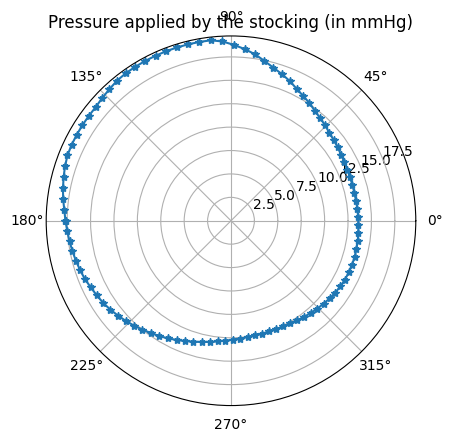

In [54]:
k = 0.39 #stiffness

# Calculate pressure (unit: N/mm²)
pressure = (k * mean_strain) / r

# Convert pressure units to mmHg
pressure_mmHg = pressure * 7500

# Show the points in a polar plot
plt.figure()
plt.polar(theta, pressure_mmHg, '-*')
plt.title('Pressure applied by the stocking (in mmHg)')
plt.show()

What is the range of pressure variation around the calf? In which location are the minimum and maximum pressures applied?

## Finite element model

The results of this analytical model can be compared with the pressure computed from a Finite Element Analysis. The simulation procedure is described in the Figure below:

![FE simulation](https://imgur.com/ruoAJUX.jpg)


They are stored in files:
- compression_NoBones_Young10kPa_compensated.DATA
- compression_WithBones_Young10kPa_compensated.DATA

Results are TAB-separated multi-column files with the following structure:

`idx | num | Initial X coordinates (mm) | Initial Y coordinates (mm) | Final X coordinates (mm) | Final Y coordinates (mm) | Pressure (MPa)`

`NoBones` stand for a leg with homogeneous properties whilst `WithBones` includes two rigid regions corresponding to the leg’s tibia and fibula.

*Note: FEM results need to be centered and the frame of reference should be reversed (X = -X and Y =-Y).*

**Plot the pressure for the three cases: analytical, FE with bones, FE without bones**

In [ ]:
nobones = np.loadtxt('Data/compression_NoBones_Young10kPa_compensated.DATA', delimiter=' ')
X_nobones =
Y_nobones =
pressure_nobones =

withbones = np.loadtxt('Data/compression_WithBones_Young10kPa_compensated.DATA', delimiter=' ')
X_withbones =
Y_withbones =
pressure_withbones =


**Comment on the differences between the analytical and numerical results.**
